# Radiographies Thoraciques - CNN from Scratch
## Detection de Pneumonie (NORMAL vs PNEUMONIA)

**Dataset :** Chest X-Ray Images (Pneumonia) - Kaggle  
**Framework :** PyTorch - Google Colab

---
### Plan
1. Importation des bibliotheques
2. Chargement des donnees
3. Data Augmentation & Preprocessing
4. Architecture CNN
5. Optimiseur, Scheduler & Initialisation
6. Boucle d'entrainement avec Early Stopping
7. Courbes d'apprentissage
8. Evaluation finale
9. Visualisation des predictions
10. Conclusion & Version amelioree

## 1. Importation des bibliotheques

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# Reproductibilite
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cuda


## 2. Chargement du Dataset

Le dataset `chest_xray` est structure en 3 splits (`train`, `val`, `test`),
chacun avec deux dossiers `NORMAL` et `PNEUMONIA`.

In [2]:
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/chest_xray'

Mounted at /content/drive


## 3. Data Augmentation & Preprocessing

**Pourquoi augmenter ?**  
Le dataset est desequilibre (~3x plus de PNEUMONIA que NORMAL).
Sans augmentation, le modele memorise les exemples d'entrainement : **overfitting**.

**Transformations sur le train :**
- `RandomHorizontalFlip` : positions miroir realistes en radiologie  
- `RandomRotation(10) + RandomAffine` : legeres distorsions geometriques  
- `ColorJitter` : variations de contraste/luminosite  
- `RandomErasing` : masque aleatoire (regularisation) - doit etre **apres** `ToTensor`  
- `Normalize(0.5, 0.5)` : centrage / reduction

**Sur val / test :** resize + normalisation uniquement.

In [3]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

# IMPORTANT : RandomErasing doit etre place APRES ToTensor
# (il travaille sur un Tensor, pas sur une image PIL)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),  # apres ToTensor
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

# Datasets & DataLoaders
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, 'val'),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, 'test'),  transform=eval_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f'Classes : {class_names}')
print(f'Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}')

targets = [lbl for _, lbl in train_dataset.samples]
print(f'Distribution train : NORMAL={targets.count(0)} | PNEUMONIA={targets.count(1)}')

Classes : ['NORMAL', 'PNEUMONIA']
Train : 5216 | Val : 16 | Test : 624
Distribution train : NORMAL=1341 | PNEUMONIA=3875


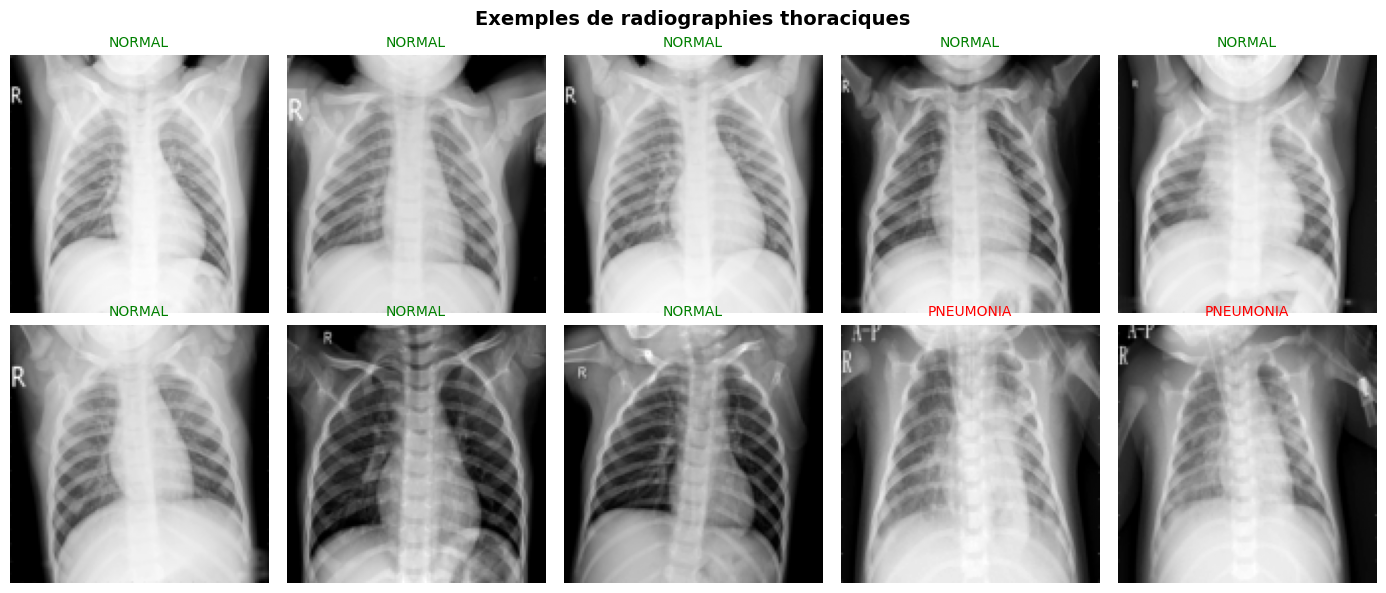

In [4]:
# Apercu du dataset
_, (imgs, lbls) = next(enumerate(val_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Exemples de radiographies thoraciques', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i][0].numpy(), cmap='gray')
    lbl = class_names[lbls[i].item()]
    ax.set_title(lbl, color='red' if lbl == 'PNEUMONIA' else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Architecture CNN (from scratch)

Architecture a 4 blocs convolutifs + **Global Average Pooling** + classifieur FC.

| Bloc | Couches | Sortie (128x128 input) |
|------|---------|------------------------|
| Bloc 1 | Conv(1->32, k=3, p=1) + BN + ReLU + MaxPool(2) | 32x64x64 |
| Bloc 2 | Conv(32->64, k=3, p=1) + BN + ReLU + MaxPool(2) | 64x32x32 |
| Bloc 3 | Conv(64->128, k=3, p=1) + BN + ReLU + MaxPool(2) | 128x16x16 |
| Bloc 4 | Conv(128->256, k=3, p=1) + BN + ReLU + MaxPool(2) | 256x8x8 |
| GAP | AdaptiveAvgPool2d(1x1) | 256 |
| FC | Linear(256->128) -> Dropout(0.4) -> Linear(128->2) | 2 |

**Techniques anti-overfitting :**
- **Batch Normalization** : stabilise et regularise implicitement
- **Global Average Pooling** : 16384 parametres en entree (Flatten) -> 256 (GAP), soit x64 moins
- **Dropout(0.4)** : 0.5 est trop agressif et peut causer de l'underfitting
- **Weight Decay** dans l'optimiseur (regularisation L2)

In [5]:
class ChestXrayCNN(nn.Module):
    """
    CNN from scratch pour la classification binaire de radiographies thoraciques.
    Architecture : 4 blocs Conv+BN+ReLU+MaxPool -> Global Average Pooling -> FC.

    Avantage du Global Average Pooling vs Flatten :
      Flatten(256, 8, 8) -> 16384 entrees au FC
      GAP(256, 1, 1)    ->   256 entrees au FC  (beaucoup moins d'overfitting)
    """
    def __init__(self, num_classes=2, dropout_rate=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1,   32),   # 128x128 -> 64x64
            conv_block(32,  64),   # 64x64   -> 32x32
            conv_block(64,  128),  # 32x32   -> 16x16
            conv_block(128, 256),  # 16x16   -> 8x8
        )

        # Global Average Pooling : 256xHxW -> 256x1x1
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return F.log_softmax(x, dim=1)


model = ChestXrayCNN(num_classes=2, dropout_rate=0.4).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametres totaux     : {total_params:,}')
print(f'Parametres trainables : {trainable_params:,}')
print()
print(model)

Parametres totaux     : 421,954
Parametres trainables : 421,954

ChestXrayCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding

## 5. Optimiseur, Scheduler & Initialisation

| Hyperparametre | Valeur | Justification |
|---|---|---|
| **Optimiseur** | Adam | Adaptatif, converge rapidement |
| **Learning Rate** | 1e-3 | Standard pour Adam |
| **Weight Decay** | 1e-4 | Regularisation L2 legere |
| **Scheduler** | ReduceLROnPlateau | Reduit le LR si val_loss stagne |
| **Init poids** | Kaiming Uniform | Adaptee aux activations ReLU |

**Poids de classe :** ~3x plus de PNEUMONIA que NORMAL.
On penalise davantage les erreurs sur la classe minoritaire (NORMAL).

In [6]:
def weights_init(layer):
    """Initialisation He (Kaiming) pour Conv & Linear, constante pour BN."""
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
        if layer.bias is not None:
            nn.init.constant_(layer.bias, 0.0)
    elif isinstance(layer, nn.BatchNorm2d):
        nn.init.constant_(layer.weight, 1.0)
        nn.init.constant_(layer.bias,  0.0)

model.apply(weights_init)
print('Poids initialises (Kaiming Uniform)')

# Poids de classe pour corriger le desequilibre NORMAL / PNEUMONIA
targets      = [lbl for _, lbl in train_dataset.samples]
class_counts = [targets.count(i) for i in range(len(class_names))]
total        = sum(class_counts)
class_weights = torch.tensor(
    [total / (len(class_names) * c) for c in class_counts], dtype=torch.float32
).to(device)
print(f'Poids de classe : NORMAL={class_weights[0]:.3f} | PNEUMONIA={class_weights[1]:.3f}')

# Optimiseur & scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print('Optimiseur et scheduler configures')

Poids initialises (Kaiming Uniform)
Poids de classe : NORMAL=1.945 | PNEUMONIA=0.673
Optimiseur et scheduler configures


## 6. Boucle d'entrainement avec Early Stopping

L'Early Stopping interrompt l'entrainement si la `val_loss` ne s'ameliore plus
pendant `patience` epoques consecutives, et sauvegarde automatiquement le meilleur modele.

In [7]:
class EarlyStopping:
    """Arrete l'entrainement si val_loss ne s'ameliore pas pendant `patience` epoques."""
    def __init__(self, patience=7, min_delta=1e-3, save_path='best_model.pt'):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter   = 0
        self.best_loss = float('inf')
        self.stop      = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            print(f'   Meilleur modele sauvegarde (val_loss={val_loss:.4f})')
        else:
            self.counter += 1
            print(f'   Patience : {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
                print('   Early stopping declenche !')

In [8]:
def train_one_epoch(model, loader, optimizer, class_weights):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss   = F.nll_loss(output, target, weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        pred        = output.argmax(dim=1)
        correct    += pred.eq(target).sum().item()
        total      += data.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, class_weights):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        output     = model(data)
        loss       = F.nll_loss(output, target, weight=class_weights, reduction='sum')
        total_loss += loss.item()
        pred        = output.argmax(dim=1)
        correct    += pred.eq(target).sum().item()
        total      += data.size(0)
    return total_loss / total, 100.0 * correct / total

In [9]:
N_EPOCHS    = 30
ES_PATIENCE = 7
SAVE_PATH   = '/content/best_chest_cnn.pt'

early_stopping = EarlyStopping(patience=ES_PATIENCE, save_path=SAVE_PATH)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

sep = '=' * 65
print(sep)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print(sep)

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, class_weights)
    val_loss,   val_acc   = evaluate(model, val_loader, class_weights)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2f}% | {val_loss:>8.4f} | {val_acc:>6.2f}%')
    if new_lr < old_lr:
        print(f'   LR reduit : {old_lr:.6f} -> {new_lr:.6f}')
    early_stopping(val_loss, model)
    if early_stopping.stop:
        print(f'\nArret a l epoque {epoch}.')
        break

print(sep)
print(f'\nEntrainement termine. Meilleure val_loss : {early_stopping.best_loss:.4f}')

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
    1 |     0.3874 |    83.38% |   4.7376 |  50.00%
   Meilleur modele sauvegarde (val_loss=4.7376)
    2 |     0.2682 |    89.53% |   0.5035 |  75.00%
   Meilleur modele sauvegarde (val_loss=0.5035)
    3 |     0.2267 |    91.79% |   2.5393 |  68.75%
   Patience : 1/7
    4 |     0.2000 |    92.66% |   1.7275 |  68.75%
   Patience : 2/7
    5 |     0.1752 |    93.96% |   3.7140 |  62.50%
   Patience : 3/7
    6 |     0.1650 |    93.92% |   2.0771 |  62.50%
   LR reduit : 0.001000 -> 0.000500
   Patience : 4/7
    7 |     0.1359 |    95.25% |   2.2115 |  68.75%
   Patience : 5/7
    8 |     0.1307 |    95.69% |   1.2347 |  75.00%
   Patience : 6/7
    9 |     0.1268 |    95.61% |   1.7606 |  68.75%
   Patience : 7/7
   Early stopping declenche !

Arret a l epoque 9.

Entrainement termine. Meilleure val_loss : 0.5035


## 7. Courbes d'apprentissage

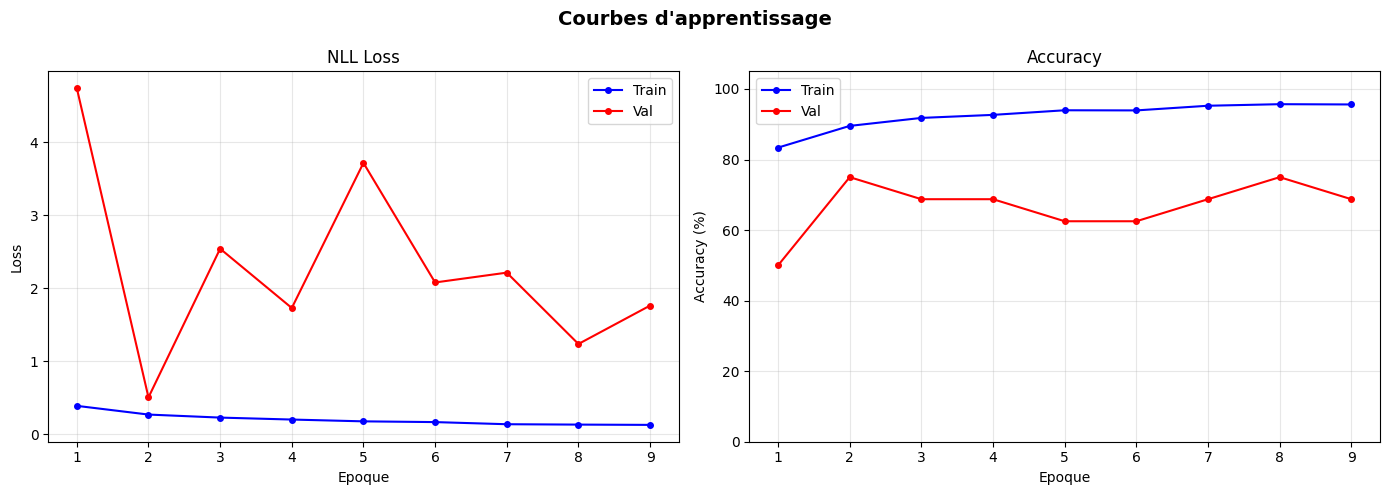

In [10]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage", fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Val')
axes[0].set_title('NLL Loss')
axes[0].set_xlabel('Epoque')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', markersize=4, label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', markersize=4, label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoque')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([0, 105])
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation finale sur le Test Set

On charge le **meilleur modele** (val_loss minimale, sauvegarde par Early Stopping)
et on calcule la matrice de confusion + rapport de classification.

In [11]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, class_weights)
print(f"{'='*40}")
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.2f}%')
print(f"{'='*40}")

  Test Loss     : 0.4097
  Test Accuracy : 80.77%


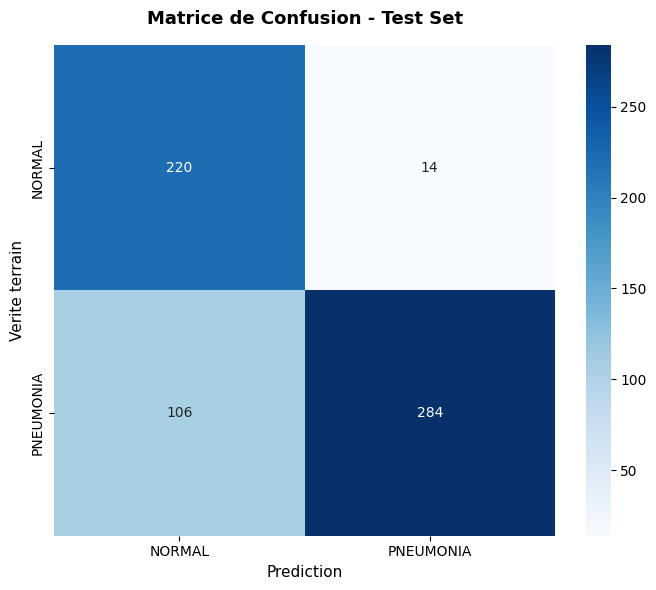


Classification Report :
              precision    recall  f1-score   support

      NORMAL     0.6748    0.9402    0.7857       234
   PNEUMONIA     0.9530    0.7282    0.8256       390

    accuracy                         0.8077       624
   macro avg     0.8139    0.8342    0.8056       624
weighted avg     0.8487    0.8077    0.8106       624



In [12]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        preds = model(data.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(target.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Matrice de Confusion - Test Set', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Prediction', fontsize=11)
ax.set_ylabel('Verite terrain', fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report :')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

## 9. Visualisation des predictions

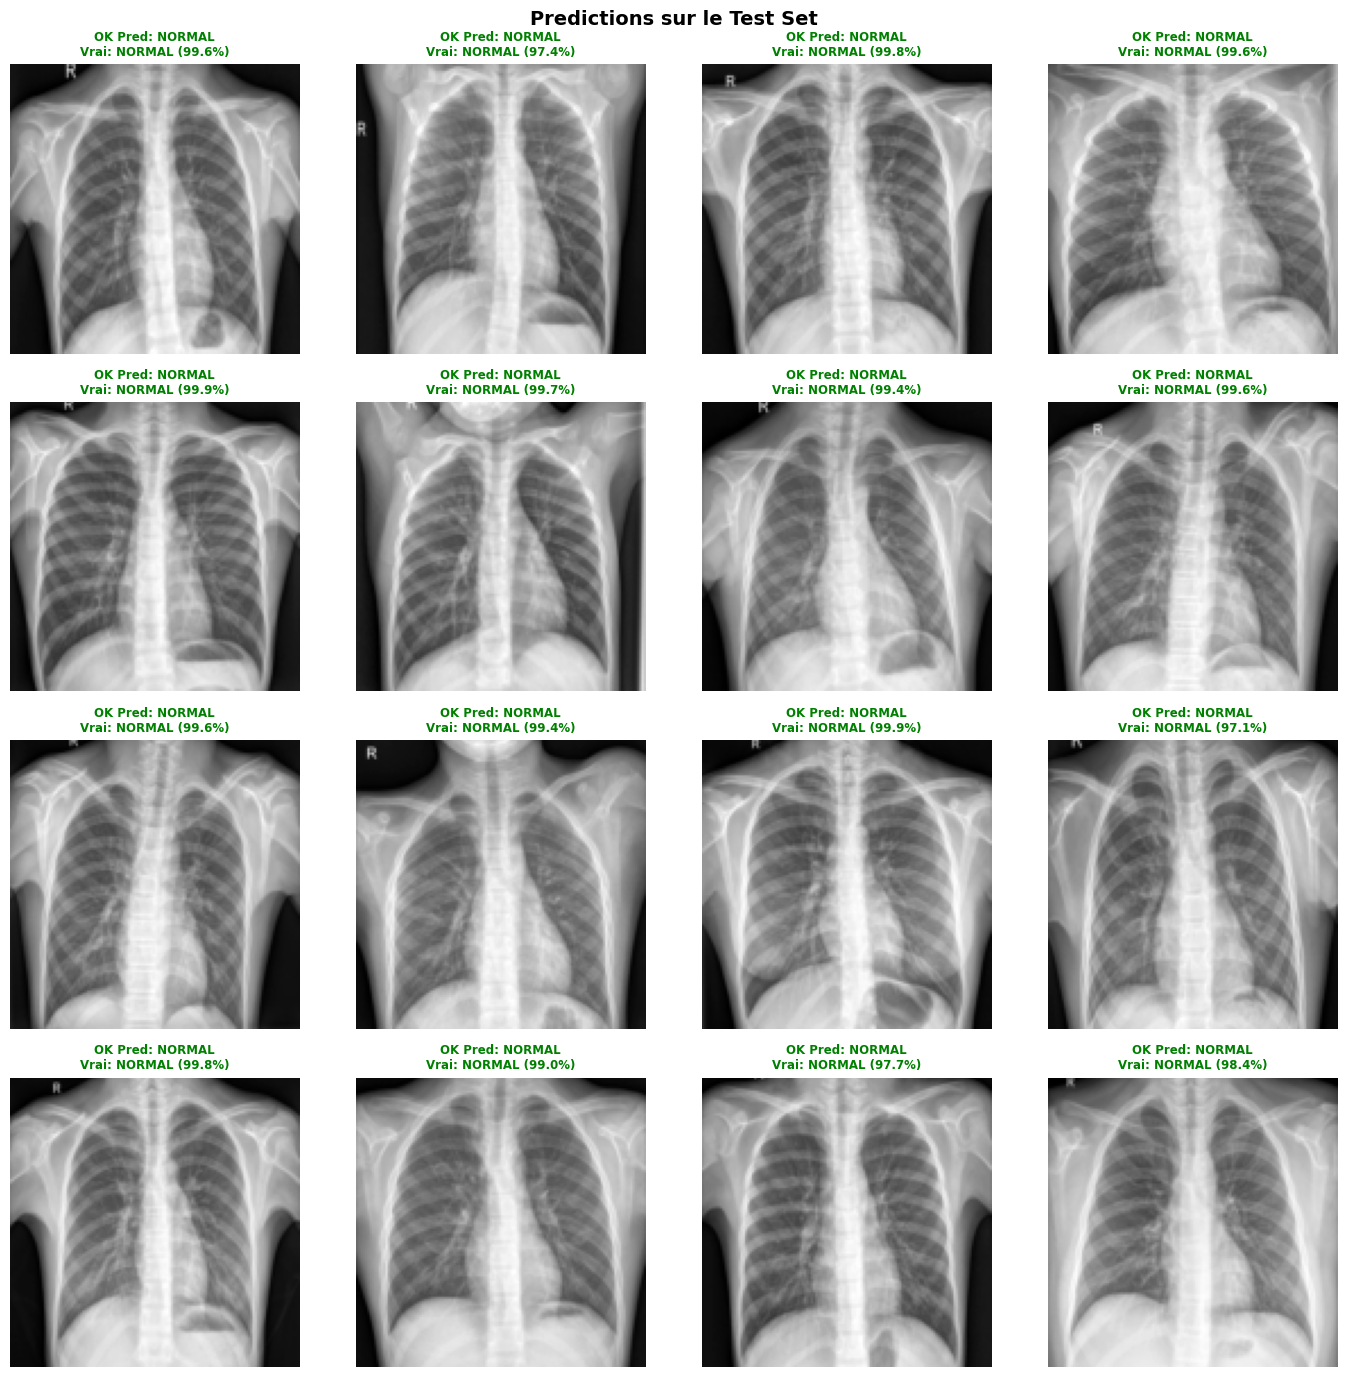

In [13]:
sample_data, sample_targets = next(iter(test_loader))
model.eval()
with torch.no_grad():
    output = model(sample_data.to(device))
    probs  = torch.exp(output).cpu()
    preds  = output.argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Predictions sur le Test Set', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= 16:
        ax.axis('off'); continue
    ax.imshow(sample_data[i][0].numpy(), cmap='gray')
    pred_lbl = class_names[preds[i].item()]
    true_lbl = class_names[sample_targets[i].item()]
    conf     = probs[i][preds[i].item()].item() * 100
    correct  = pred_lbl == true_lbl
    ax.set_title(
        f"{'OK' if correct else 'ERR'} Pred: {pred_lbl}\nVrai: {true_lbl} ({conf:.1f}%)",
        color='green' if correct else 'red', fontsize=8.5, fontweight='bold'
    )
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusion

### Corrections apportees (anti-overfitting)

| Probleme | Solution |
|----------|----------|
| **Bug `RandomErasing`** avant `ToTensor` | Deplace apres `ToTensor` (fonctionne sur Tensor, pas PIL) |
| **Flatten** -> trop de parametres (16384) | **Global Average Pooling** -> 256 entrees (x64 moins) |
| **Dropout 0.5** trop agressif | Dropout 0.4 : meilleur equilibre |
| Code repetitif (4 blocs identiques) | Fonction `conv_block` helper (DRY) |
| Poids de classe recalcules 2 fois | Calcul unique, reutilise en V2 |

### Techniques anti-overfitting completes

| Technique | Role |
|-----------|------|
| **Data Augmentation** | Diversifie les exemples d'entrainement |
| **Batch Normalization** | Stabilise et regularise implicitement |
| **Global Average Pooling** | Reduit massivement les parametres du FC |
| **Dropout (0.4)** | Desactive des neurones aleatoirement |
| **Weight Decay (1e-4)** | Penalise les grands poids (L2) |
| **Early Stopping** | Sauvegarde le modele avant l'overfitting |
| **Poids de classe** | Compense le desequilibre NORMAL/PNEUMONIA |

### Pistes d'amelioration
- Images 224x224 pour plus de details (voir section bonus)
- Reseau residuel (ResNet-like) pour gradients plus stables
- **AdamW** + **Cosine Annealing** (voir ci-dessous)
- **Focal Loss** pour mieux gerer le desequilibre de classes

## Version amelioree (224x224, AdamW, CosineAnnealing)

Cette version utilise des images plus grandes, AdamW (meilleure regularisation que Adam)
et un scheduler Cosine Annealing pour un apprentissage plus progressif.

In [14]:
IMAGE_SIZE_V2 = 224
BATCH_SIZE_V2 = 16   # batch reduit car images plus grandes

train_transform_v2 = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE_V2, IMAGE_SIZE_V2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # apres ToTensor
])

eval_transform_v2 = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE_V2, IMAGE_SIZE_V2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

train_ds_v2 = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform_v2)
val_ds_v2   = datasets.ImageFolder(os.path.join(data_dir, 'val'),   transform=eval_transform_v2)
test_ds_v2  = datasets.ImageFolder(os.path.join(data_dir, 'test'),  transform=eval_transform_v2)

train_ld_v2 = torch.utils.data.DataLoader(train_ds_v2, batch_size=BATCH_SIZE_V2, shuffle=True,  num_workers=2, pin_memory=True)
val_ld_v2   = torch.utils.data.DataLoader(val_ds_v2,   batch_size=BATCH_SIZE_V2, shuffle=False, num_workers=2, pin_memory=True)
test_ld_v2  = torch.utils.data.DataLoader(test_ds_v2,  batch_size=BATCH_SIZE_V2, shuffle=False, num_workers=2, pin_memory=True)

# Meme architecture : AdaptiveAvgPool s'adapte automatiquement a 224x224
model_v2 = ChestXrayCNN(num_classes=2, dropout_rate=0.4).to(device)
model_v2.apply(weights_init)

# AdamW (meilleure regularisation) + CosineAnnealing (LR progressif)
optimizer_v2 = optim.AdamW(model_v2.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=30, eta_min=1e-6)

# Poids de classe pour V2 (calcul unique, pas de duplication)
targets_v2 = [lbl for _, lbl in train_ds_v2.samples]
counts_v2  = [targets_v2.count(i) for i in range(2)]
cw_v2 = torch.tensor(
    [sum(counts_v2) / (2 * c) for c in counts_v2], dtype=torch.float32
).to(device)

es_v2      = EarlyStopping(patience=8, save_path='/content/best_chest_cnn_v2.pt')
history_v2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Version amelioree (224x224 | AdamW | CosineAnnealing)')
sep = '=' * 65
print(sep)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print(sep)

for epoch in range(1, 31):
    tr_loss, tr_acc = train_one_epoch(model_v2, train_ld_v2, optimizer_v2, cw_v2)
    va_loss, va_acc = evaluate(model_v2, val_ld_v2, cw_v2)
    scheduler_v2.step()

    history_v2['train_loss'].append(tr_loss)
    history_v2['val_loss'].append(va_loss)
    history_v2['train_acc'].append(tr_acc)
    history_v2['val_acc'].append(va_acc)

    print(f'{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | {va_loss:>8.4f} | {va_acc:>6.2f}%')
    es_v2(va_loss, model_v2)
    if es_v2.stop:
        print(f'\nArret a l epoque {epoch}.')
        break

print(sep)
model_v2.load_state_dict(torch.load('/content/best_chest_cnn_v2.pt', map_location=device))
_, test_acc_v2 = evaluate(model_v2, test_ld_v2, cw_v2)
print(f'\nVersion amelioree - Test Accuracy : {test_acc_v2:.2f}%')

Version amelioree (224x224 | AdamW | CosineAnnealing)
Epoch | Train Loss | Train Acc | Val Loss | Val Acc
    1 |     0.4629 |    80.27% |   4.4403 |  62.50%
   Meilleur modele sauvegarde (val_loss=4.4403)
    2 |     0.3848 |    85.26% |   1.7971 |  81.25%
   Meilleur modele sauvegarde (val_loss=1.7971)
    3 |     0.3518 |    86.81% |   3.4839 |  68.75%
   Patience : 1/8
    4 |     0.3285 |    87.62% |   3.4142 |  62.50%
   Patience : 2/8
    5 |     0.2962 |    89.42% |   2.4135 |  62.50%
   Patience : 3/8
    6 |     0.2830 |    90.18% |   2.9078 |  62.50%
   Patience : 4/8
    7 |     0.2465 |    91.45% |   0.4904 |  81.25%
   Meilleur modele sauvegarde (val_loss=0.4904)
    8 |     0.2427 |    91.87% |   1.0053 |  81.25%
   Patience : 1/8
    9 |     0.2362 |    91.68% |   1.5799 |  68.75%
   Patience : 2/8
   10 |     0.2162 |    92.62% |   1.3477 |  81.25%
   Patience : 3/8
   11 |     0.2231 |    92.24% |   2.6385 |  62.50%
   Patience : 4/8
   12 |     0.2197 |    93.10% |  